In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AML_LAB/spam_email.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
df['Category'] = df['Category'].astype(str).str.strip().str.lower()
df['Category'] = pd.get_dummies(df['Category'], drop_first = True)
df

,Category,Message
0,False,"Go until jurong point, crazy.. Available only ..."
1,False,Ok lar... Joking wif u oni...
2,True,Free entry in 2 a wkly comp to win FA Cup fina...
3,False,U dun say so early hor... U c already then say...
4,False,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,True,This is the 2nd time we have tried 2 contact u...
5568,False,Will ü b going to esplanade fr home?
5569,False,"Pity, * was in mood for that. So...any other s..."
5570,False,The guy did some bitching but I acted like i'd...


In [ ]:
tfidfconverter = TfidfVectorizer(stop_words="english")
X = tfidfconverter.fit_transform(df['Message']).toarray()
y = df['Category']

print("Data preprocessing complete. The first 5 rows of the DataFrame with processed messages are:")
print(df[['Message', 'Category']].head())
print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)
print("Number of NaN values in y after processing:", np.isnan(y).sum())

Data preprocessing complete. The first 5 rows of the DataFrame with processed messages are:
                                             Message  Category
0  Go until jurong point, crazy.. Available only ...     False
1                      Ok lar... Joking wif u oni...     False
2  Free entry in 2 a wkly comp to win FA Cup fina...      True
3  U dun say so early hor... U c already then say...     False
4  Nah I don't think he goes to usf, he lives aro...     False
Shape of feature matrix X: (5572, 8440)
Shape of target vector y: (5572,)
Number of NaN values in y after processing: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (4457, 8440)
X_test shape: (1115, 8440)
y_train shape: (4457,)
y_test shape: (1115,)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score, precision_score


NB = MultinomialNB()
LR = LogisticRegression(random_state=42, max_iter=1000)
SVM = SVC(random_state=42)
DT = DecisionTreeClassifier(random_state=42)
RF = RandomForestClassifier(random_state=42)

In [ ]:
NB.fit(X_train, y_train)

MultinomialNB()

In [ ]:
LR.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
SVM.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
DT.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
RF.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_nb = NB.predict(X_test)
y_pred_lr = LR.predict(X_test)
y_pred_svm = SVM.predict(X_test)
y_pred_dt = DT.predict(X_test)
y_pred_rf = RF.predict(X_test)

In [ ]:
acc_NB = accuracy_score(y_test, y_pred_nb)
acc_LR = accuracy_score(y_test, y_pred_lr)
acc_SVM = accuracy_score(y_test, y_pred_svm)
acc_DT = accuracy_score(y_test, y_pred_dt)
acc_RF = accuracy_score(y_test, y_pred_rf)

In [ ]:
recall_NB = recall_score(y_test, y_pred_nb)
recall_LR = recall_score(y_test, y_pred_lr)
recall_SVM = recall_score(y_test, y_pred_svm)
recall_DT = recall_score(y_test, y_pred_dt)
recall_RF = recall_score(y_test, y_pred_rf)

In [ ]:
precision_score_NB = precision_score(y_test, y_pred_nb)
precision_score_LR = precision_score(y_test, y_pred_lr)
precision_score_SVM = precision_score(y_test, y_pred_svm)
precision_score_DT = precision_score(y_test, y_pred_dt)
precision_score_RF = precision_score(y_test, y_pred_rf)

In [ ]:
f1_score_NB = f1_score(y_test, y_pred_nb)
f1_score_LR = f1_score(y_test, y_pred_lr)
f1_score_SVM = f1_score(y_test, y_pred_svm)
f1_score_DT = f1_score(y_test, y_pred_dt)
f1_score_RF = f1_score(y_test, y_pred_rf)

In [ ]:
Model = ['NB', 'LR', 'SVM', 'DT', 'RF']
Accuracy = [acc_NB, acc_LR, acc_SVM, acc_DT, acc_RF]
Recall = [recall_NB, recall_LR, recall_SVM, recall_DT, recall_RF]
Precision = [precision_score_NB, precision_score_LR, precision_score_SVM, precision_score_DT, precision_score_RF]
F1_Score = [f1_score_NB, f1_score_LR, f1_score_SVM, f1_score_DT, f1_score_RF]

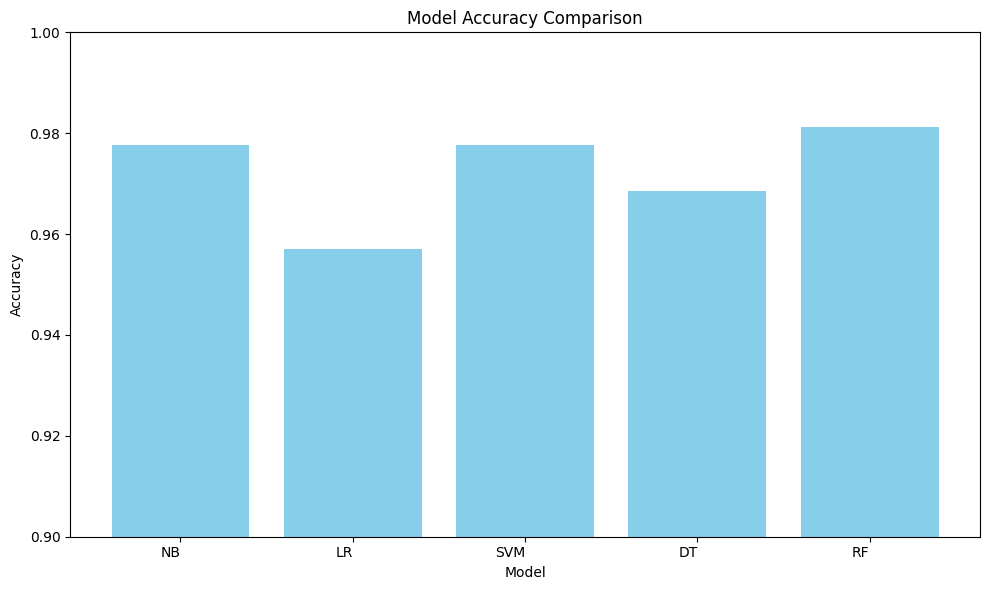

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, Accuracy, color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0.9, 1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

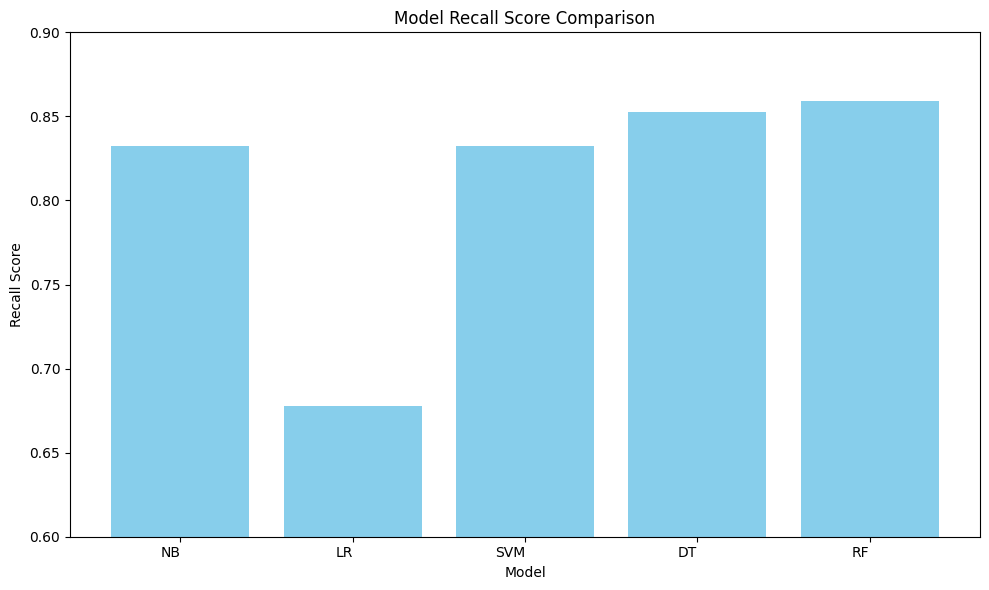

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(Model, Recall, color='skyblue')
plt.title('Model Recall Score Comparison')
plt.ylabel('Recall Score')
plt.xlabel('Model')
plt.ylim(0.6, 0.9)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

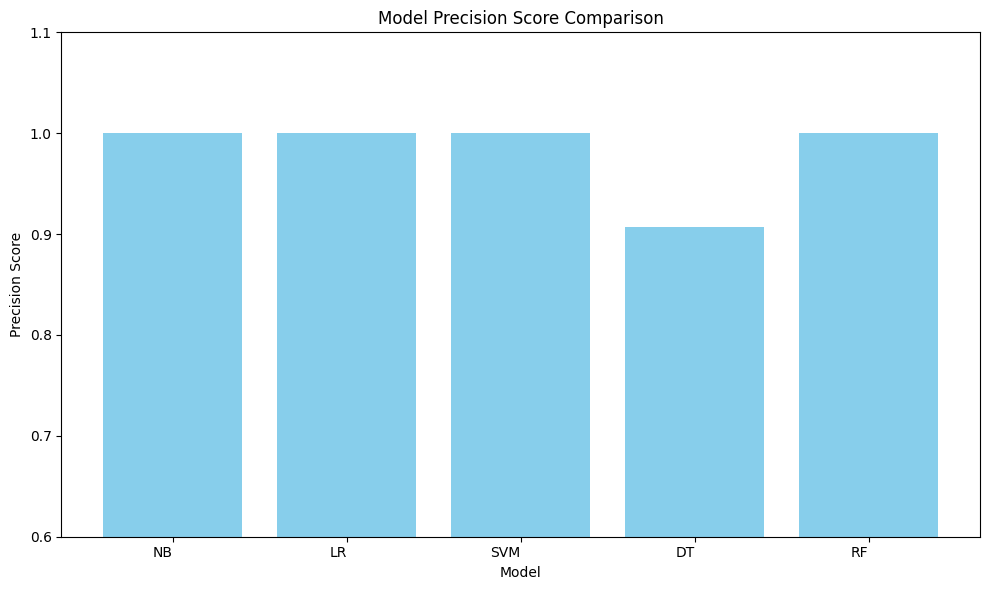

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(Model, Precision, color='skyblue')
plt.title('Model Precision Score Comparison')
plt.ylabel('Precision Score')
plt.xlabel('Model')
plt.ylim(0.6, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

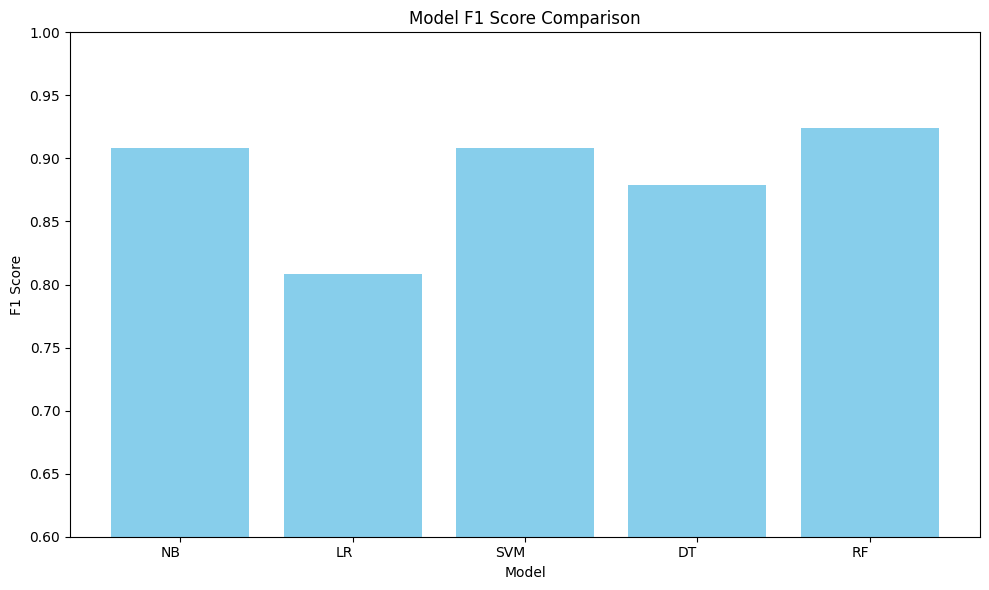

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(Model, F1_Score, color='skyblue')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.ylim(0.6, 1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

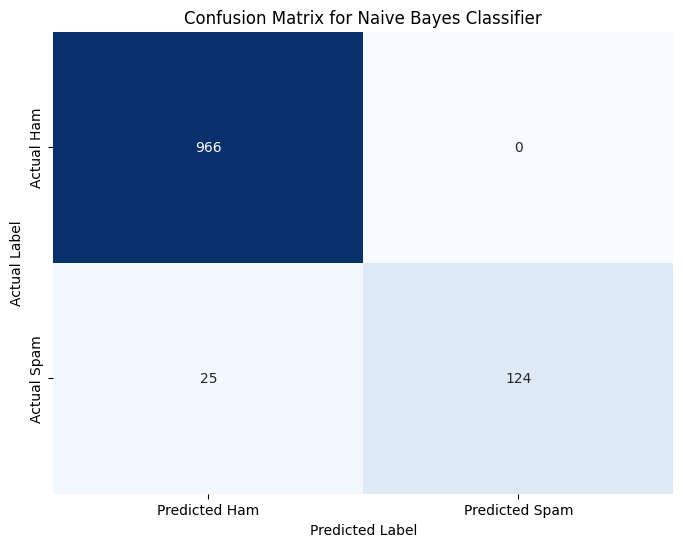

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

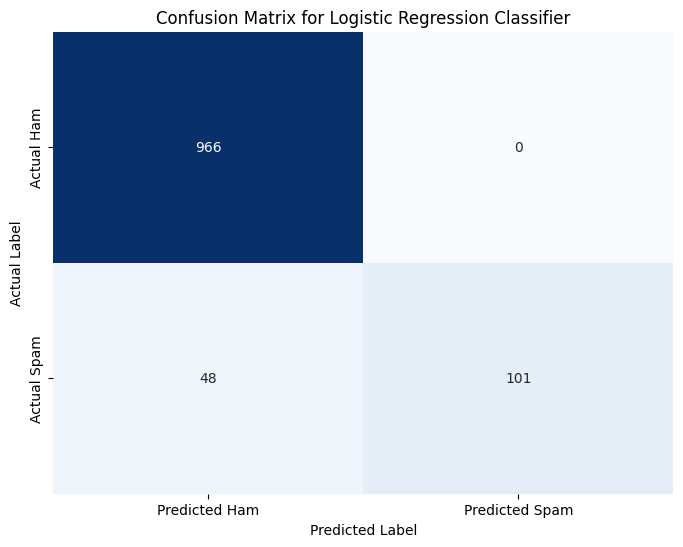

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix for Logistic Regression Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

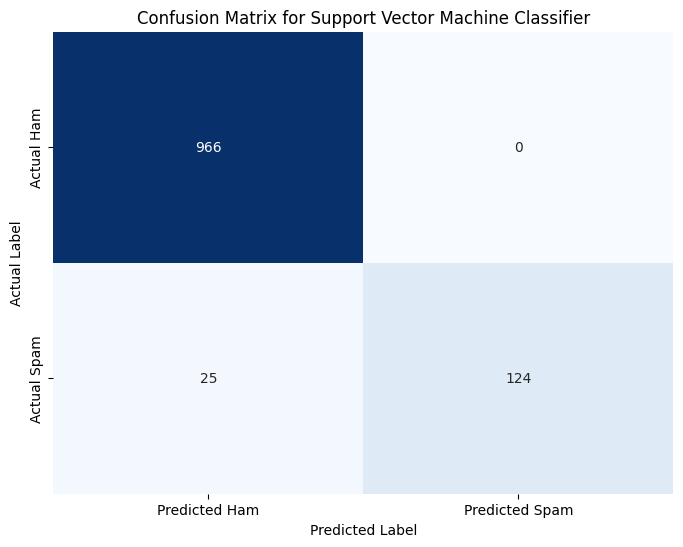

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix for Support Vector Machine Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

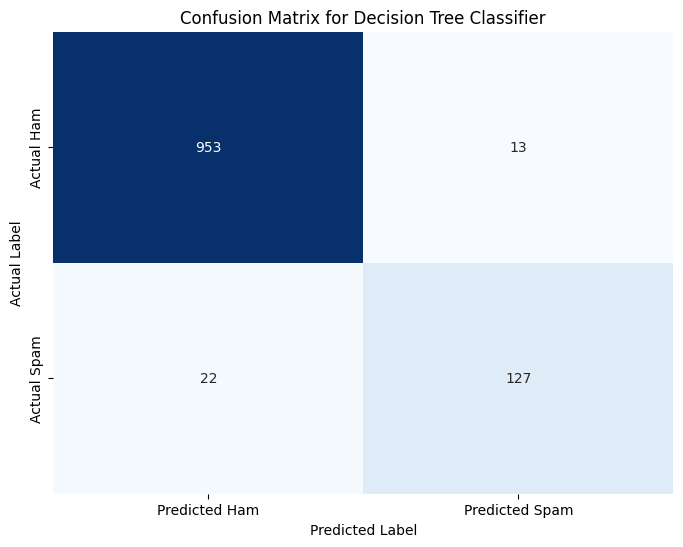

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

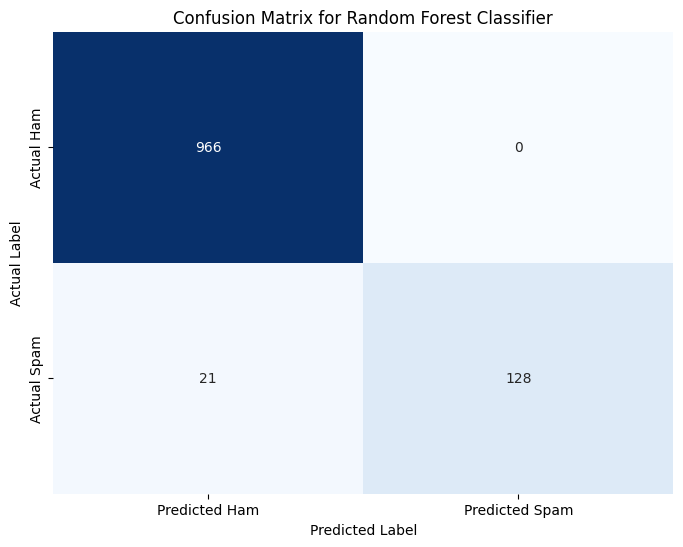

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()